In [3]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

print("Everything imported successfully")
print("Scikit-learn version:", sklearn.__version__)

Everything imported successfully
Scikit-learn version: 1.9.1


In [4]:
import pandas as pd

data = pd.read_csv("eye_closure.csv")

print(data.head())
print(data.columns)

   closure_ratio  avg_closure_ms  blink_rate  label
0           0.08             120          20  Alert
1           0.10             140          18  Alert
2           0.12             160          19  Alert
3           0.15             180          17  Alert
4           0.11             130          21  Alert
Index(['closure_ratio', 'avg_closure_ms', 'blink_rate', 'label'], dtype='str')


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

x = data[["closure_ratio", "avg_closure_ms", "blink_rate"]]
y = data["label"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=3,
    random_state=42
)

model.fit(x_train, y_train)

pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 1.0
              precision    recall  f1-score   support

       Alert       1.00      1.00      1.00         5
      Drowsy       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [7]:
new_driver = pd.DataFrame(
    [[0.48, 850, 4]],
    columns=["closure_ratio", "avg_closure_ms", "blink_rate"]
)

print("Prediction:", model.predict(new_driver)[0])

Prediction: Drowsy


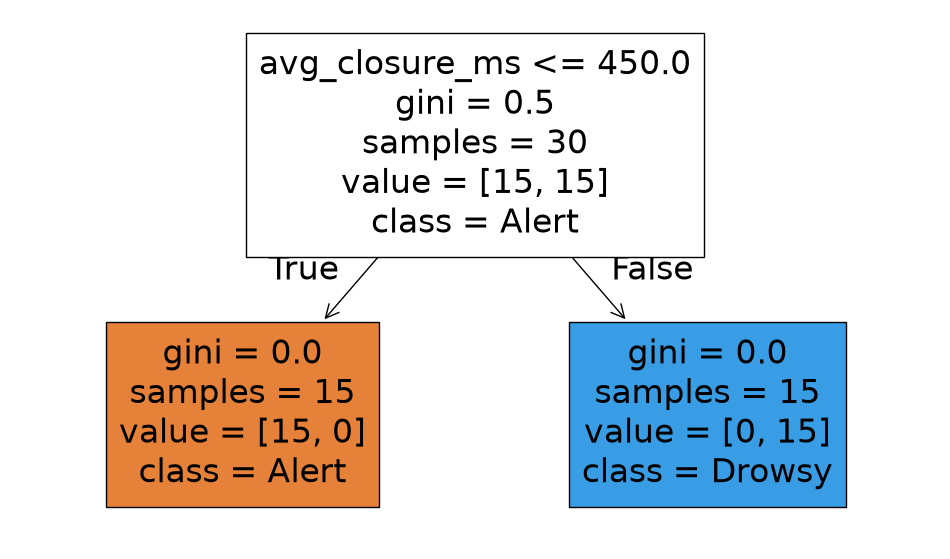

In [8]:
plt.figure(figsize=(12, 7))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=model.classes_,
    filled=True
)

plt.show()